RCIModel elapsed time: 5.167300e-03 s
Ketcham2007 elapsed time: 4.101000e-04 s
RCI é 1260.0% do tempo do Ketcham2007

=== AFT RESULTS TABLE ===
  Thermal_history        Model  ETCH_PIT_LENGTH AFT_source AFT_dataset  \
0           wolf1     RCIModel             1.65    dataset      Miller   
1           wolf1  Ketcham2007             1.65    dataset      Miller   

   AFT_age_Ma  Mean_track_length_um     Sigma  Central_age_Ma  Central_age_se  \
0   45.717351             14.981018  1.121516          175.57            8.51   
1   44.598919             14.751103  1.068583          175.57            8.51   

   Pooled_age_Ma  Pooled_age_se      Chi2  
0         175.57           8.51  0.929213  
1         175.57           8.51  0.929213  


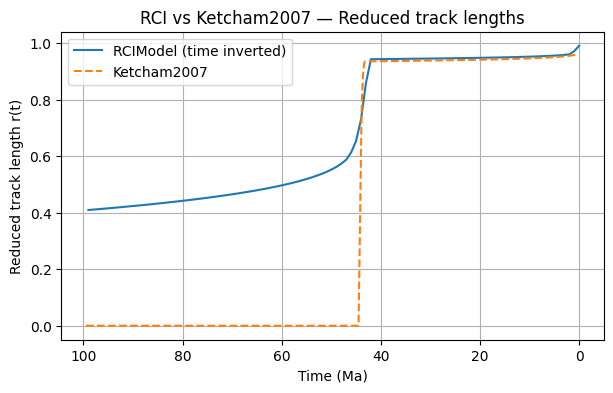

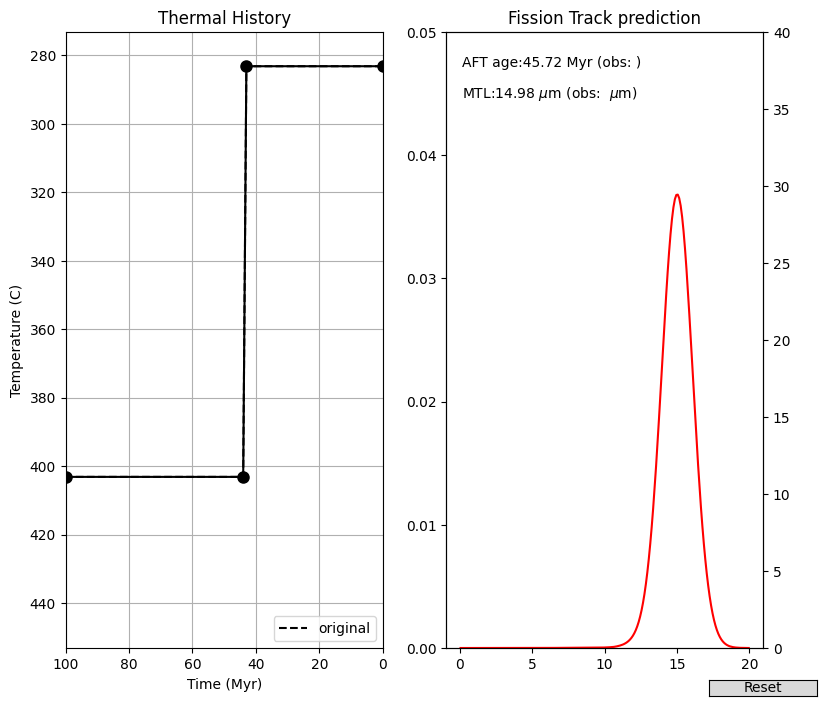

In [1]:
# ============================================================
# PYFTRACKS — MODULAR AFT FRAMEWORK (MERGED)
# Estrutura: CONFIG → BUILD → RUN → OUTPUT
# ============================================================

import sys
sys.path.append(r"H:\My Drive\PD\Projeto_PD_Annealing\04_SOFTWARE\pyFTracks-legacy")
import time
import pyFTracks as FT
import matplotlib.pyplot as plt
import pandas as pd



from pyFTracks import ressources
from pyFTracks.thermal_history import WOLF1


# ============================================================
# 0) CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

CONFIG = {
    # ---- História térmica ----
    "thermal_history": {
        "mode": "object",          # "object" | "manual"
        "object": WOLF1,           # usado se mode="object"

        # usado se mode="manual"
        "manual": {
            "name": "Manual_TH",
            "time": None,
            "temperature": None
        }
    },

    # ---- Modelo cinético ----
    "model": {
        "type": "RCIModel",        # "Ketcham1999" | "Ketcham2007" | "RCIModel"
        "ETCH_PIT_LENGTH": 1.65
    },

    # ---- Dados AFT (ζ-method) ----
    "aft_data": {
        "source": "dataset",       # "dataset" | "manual"
        "dataset_name": "Miller",

        "manual": {
            "Ns": [31, 19, 56, 67, 88, 6, 18, 40, 36, 54, 35, 52, 51, 47, 27, 36, 64, 68, 61, 30],
            "Ni": [41, 22, 63, 71, 90, 7, 14, 41, 49, 79, 52, 76, 74, 66, 39, 44, 86, 90, 91, 41],
            "zeta": 350.,
            "zeta_err": 10. / 350.,
            "rhod": 1.304,
            "Nd": 2936
        }
    }
}


# ============================================================
# 1) BUILD — História térmica
# ============================================================

def build_thermal_history(cfg):
    if cfg["mode"] == "object":
        return cfg["object"]

    elif cfg["mode"] == "manual":
        m = cfg["manual"]
        return FT.ThermalHistory(
            name=m["name"],
            time=m["time"],
            temperature=m["temperature"]
        )

    else:
        raise ValueError("thermal_history.mode inválido")

thermal_history = build_thermal_history(CONFIG["thermal_history"])


# ============================================================
# 2) BUILD — Modelo cinético
# ============================================================

def build_model(cfg, thermal_history):
    params = {"ETCH_PIT_LENGTH": cfg["ETCH_PIT_LENGTH"]}
    t = cfg["type"]

    if t == "Ketcham1999":
        model = FT.Ketcham1999(kinetic_parameters=params)
    elif t == "Ketcham2007":
        model = FT.Ketcham2007(kinetic_parameters=params)
    elif t == "RCIModel":
        model = FT.RCIModel(kinetic_parameters=params)
    else:
        raise ValueError(f"Modelo não suportado: {t}")

    model.history = thermal_history
    return model

annealing_model = build_model(CONFIG["model"], thermal_history)


# ============================================================
# 3) RUN — Forward modelling + benchmark
# ============================================================

start = time.perf_counter()
annealing_model.calculate_age()
elapsed_rci = time.perf_counter() - start

ketcham_model = FT.Ketcham2007(
    kinetic_parameters={"ETCH_PIT_LENGTH": CONFIG["model"]["ETCH_PIT_LENGTH"]}
)
ketcham_model.history = thermal_history

start = time.perf_counter()
ketcham_model.calculate_age()
elapsed_ketcham = time.perf_counter() - start

print(f"RCIModel elapsed time: {elapsed_rci:.6e} s")
print(f"Ketcham2007 elapsed time: {elapsed_ketcham:.6e} s")
if elapsed_ketcham > 0:
    print(f"RCI é {100 * elapsed_rci / elapsed_ketcham:.1f}% do tempo do Ketcham2007")


# ============================================================
# 4) RUN — Estatística AFT (ζ-method)
# ============================================================

def load_aft_data(cfg):
    if cfg["source"] == "dataset":
        d = getattr(ressources, cfg["dataset_name"])
        return {
            "Ns": d.Ns,
            "Ni": d.Ni,
            "zeta": d.zeta,
            "zeta_err": getattr(d, "zeta_err", 0.0),
            "rhod": d.rhod,
            "Nd": d.nd
        }

    elif cfg["source"] == "manual":
        return cfg["manual"]

    else:
        raise ValueError("aft_data.source inválido")

aft = load_aft_data(CONFIG["aft_data"])

central = FT.central_age(aft["Ns"], aft["Ni"], aft["zeta"],
                          aft["zeta_err"], aft["rhod"], aft["Nd"])
pooled = FT.pooled_age(aft["Ns"], aft["Ni"], aft["zeta"],
                        aft["zeta_err"], aft["rhod"], aft["Nd"])
chi2 = FT.chi2_test(aft["Ns"], aft["Ni"])


# ============================================================
# 5) OUTPUT — Tabela de resultados
# ============================================================

df_results = pd.DataFrame([
    {
        "Thermal_history": thermal_history.name,
        "Model": "RCIModel",
        "ETCH_PIT_LENGTH": CONFIG["model"]["ETCH_PIT_LENGTH"],
        "AFT_source": CONFIG["aft_data"]["source"],
        "AFT_dataset": CONFIG["aft_data"].get("dataset_name", "manual"),
        "AFT_age_Ma": annealing_model.ft_model_age,
        "Mean_track_length_um": annealing_model.MTL,
        "Sigma": annealing_model.STD,
        "Central_age_Ma": central["Central"],
        "Central_age_se": central["se"],
        "Pooled_age_Ma": pooled["Pooled Age"],
        "Pooled_age_se": pooled["se"],
        "Chi2": chi2
    },
    {
        "Thermal_history": thermal_history.name,
        "Model": "Ketcham2007",
        "ETCH_PIT_LENGTH": CONFIG["model"]["ETCH_PIT_LENGTH"],
        "AFT_source": CONFIG["aft_data"]["source"],
        "AFT_dataset": CONFIG["aft_data"].get("dataset_name", "manual"),
        "AFT_age_Ma": ketcham_model.ft_model_age,
        "Mean_track_length_um": ketcham_model.MTL,
        "Sigma": ketcham_model.STD,
        "Central_age_Ma": central["Central"],
        "Central_age_se": central["se"],
        "Pooled_age_Ma": pooled["Pooled Age"],
        "Pooled_age_se": pooled["se"],
        "Chi2": chi2
    }
])

print("\n=== AFT RESULTS TABLE ===")
print(df_results)


# ============================================================
# 6) OUTPUT — Gráfico r(t) (RCI com tempo invertido)
# ============================================================

t = annealing_model.history.time
t_mid = 0.5 * (t[:-1] + t[1:])

# inverter APENAS o tempo do RCI
t_mid_rci = t_mid.max() - t_mid

plt.figure(figsize=(7, 4))
plt.plot(t_mid_rci, annealing_model.reduced_lengths, '-', label="RCIModel (time inverted)")
plt.plot(t_mid, ketcham_model.reduced_lengths, '--', label="Ketcham2007")

plt.gca().invert_xaxis()
plt.xlabel("Time (Ma)")
plt.ylabel("Reduced track length r(t)")
plt.title("RCI vs Ketcham2007 — Reduced track lengths")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# 7) OUTPUT — Viewer interativo
# ============================================================

FT.Viewer(history=thermal_history, annealing_model=annealing_model)


In [5]:
def run_for_history(th):
    global annealing_model, ketcham_model, thermal_history

    thermal_history = th
    annealing_model.history = thermal_history
    ketcham_model.history = thermal_history

    annealing_model.calculate_age()
    ketcham_model.calculate_age()

    return [
        {
            "Thermal_history": thermal_history.name,
            "Model": "RCIModel",
            "AFT_age_Ma": annealing_model.ft_model_age,
            "MTL": annealing_model.MTL,
            "Sigma": annealing_model.STD
        },
        {
            "Thermal_history": thermal_history.name,
            "Model": "Ketcham2007",
            "AFT_age_Ma": ketcham_model.ft_model_age,
            "MTL": ketcham_model.MTL,
            "Sigma": ketcham_model.STD
        }
    ]
from pyFTracks.thermal_history import (
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
)

histories = [
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
]

rows = []
for th in histories:
    rows.extend(run_for_history(th))

df_all = pd.DataFrame(rows)
print(df_all)


   Thermal_history        Model  AFT_age_Ma        MTL     Sigma
0            wolf1     RCIModel   45.717351  14.981018  1.121516
1            wolf1  Ketcham2007   44.598919  14.751103  1.068583
2            wolf2     RCIModel   66.752709  13.760753  1.669865
3            wolf2  Ketcham2007   61.204023  13.583548  1.579917
4            wolf3     RCIModel   89.922718  13.451887  1.456536
5            wolf3  Ketcham2007   84.290582  12.821024  1.899805
6            wolf4     RCIModel   86.484617  13.298218  1.514216
7            wolf4  Ketcham2007   80.528209  12.759710  1.726996
8            wolf5     RCIModel   84.872200  12.906098  1.607372
9            wolf5  Ketcham2007    7.779969  13.962700  1.563079
10       Flaxmans1     RCIModel   30.038687  12.069828  1.393163
11       Flaxmans1  Ketcham2007    0.000000        NaN       NaN
12          Vrolij     RCIModel  198.765611  14.739197  1.057193
13          Vrolij  Ketcham2007  201.378584  14.273979  1.049495


C:\Users\MatheusRufino\AppData\Local\Temp\ipykernel_7712\378429310.py:9: RuntimeWarning: invalid value encountered in divide
  ketcham_model.calculate_age()


C:\Users\MatheusRufino\AppData\Local\Temp\ipykernel_7712\378429310.py:9: RuntimeWarning: invalid value encountered in divide
  ketcham_model.calculate_age()


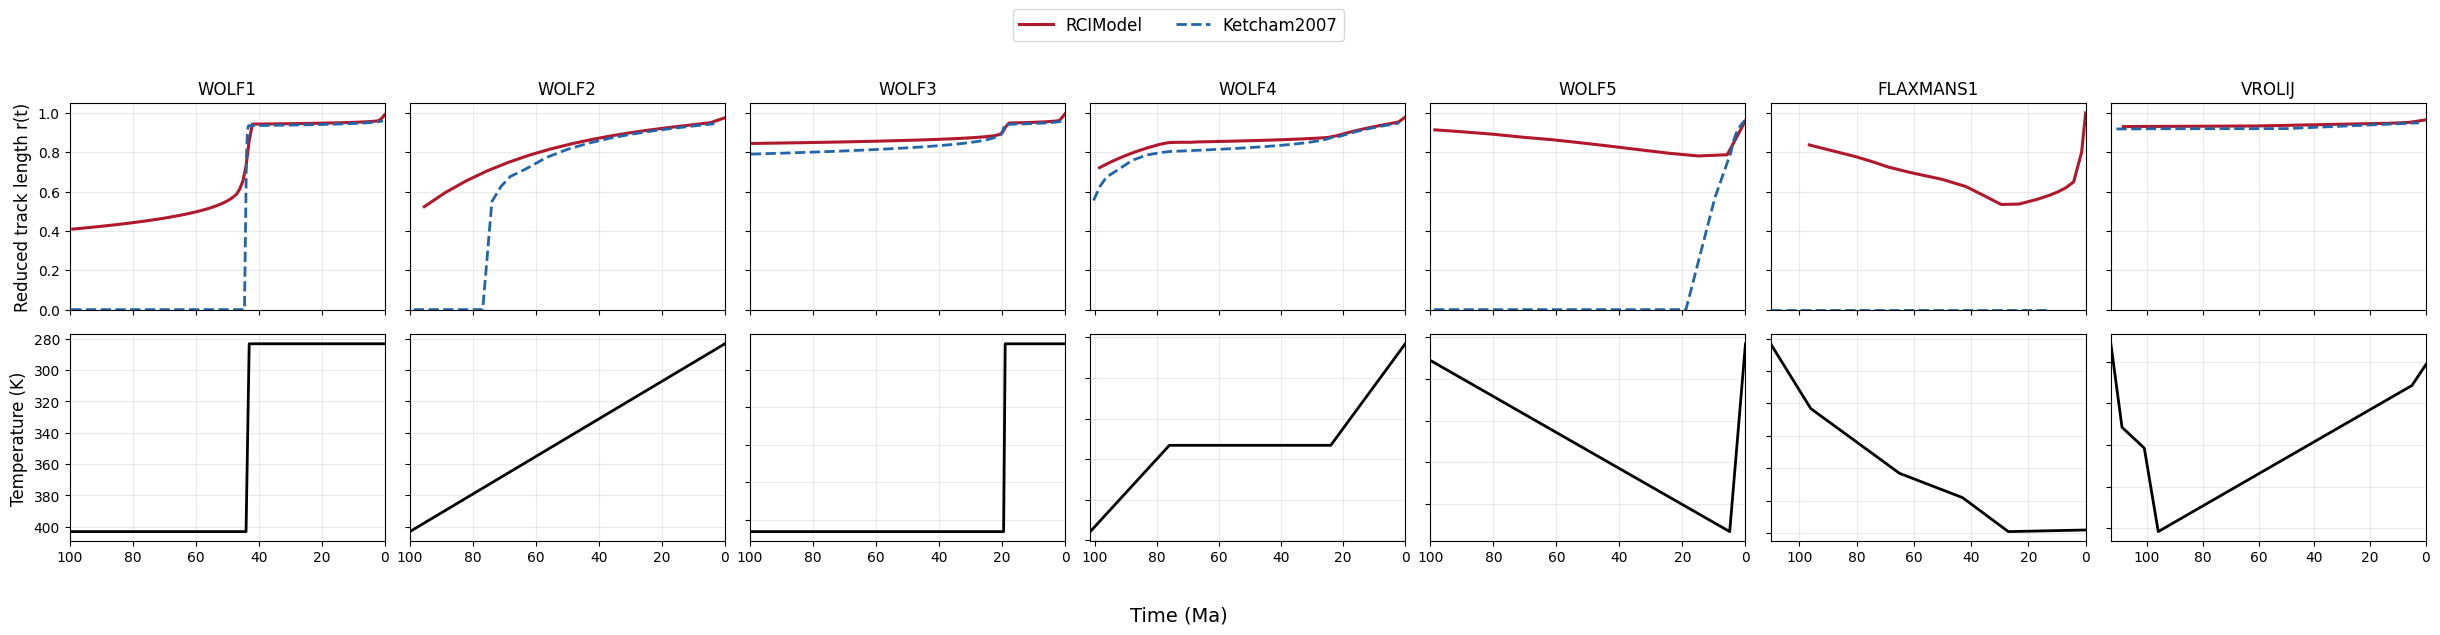

In [8]:
from pyFTracks.thermal_history import (
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
)
import matplotlib.pyplot as plt
import numpy as np

# Paleta recomendada (journal-safe)
COLOR_RCI_LINE = "#B2182B"     # vermelho escuro (brick red)
COLOR_RCI_FILL = "#EF8A62"     # vermelho claro desaturado
COLOR_KETCHAM  = "#2166AC"     # azul profundo
EDGE_COLOR     = "k"


histories = [
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
]

fig, axes = plt.subplots(
    2, len(histories),
    figsize=(3.6 * len(histories), 6)
)
for i, th in enumerate(histories):
    run_for_history(th)

    # =========================
    # Linha 1 — r(t)
    # =========================
    ax_rt = axes[0, i]

    t = annealing_model.history.time
    t_mid = 0.5 * (t[:-1] + t[1:])
    t_mid_rci = t_mid.max() - t_mid

    ax_rt.plot(
        t_mid_rci,
        annealing_model.reduced_lengths,
        color=COLOR_RCI_LINE,
        linewidth=2.2,
        label="RCIModel"
    )

    ax_rt.plot(
        t_mid,
        ketcham_model.reduced_lengths,
        linestyle="--",
        color=COLOR_KETCHAM,
        linewidth=2.0,
        label="Ketcham2007"
    )

    ax_rt.set_xlim(t.max(), t.min())
    ax_rt.set_ylim(0, 1.05)
    ax_rt.grid(True, alpha=0.25)
    ax_rt.set_title(th.name.upper(), fontsize=12)

    if i == 0:
        ax_rt.set_ylabel("Reduced track length r(t)", fontsize=12)
    else:
        ax_rt.tick_params(labelleft=False)

    ax_rt.tick_params(labelbottom=False)

    # =========================
    # Linha 2 — Thermal history
    # =========================
    ax_th = axes[1, i]

    ax_th.plot(th.time, th.temperature, "k-", linewidth=2)
    ax_th.set_xlim(t.max(), t.min())
    ax_th.invert_yaxis()
    ax_th.grid(True, alpha=0.25)

    if i == 0:
        ax_th.set_ylabel("Temperature (K)", fontsize=12)

    else:
        ax_th.tick_params(labelleft=False)

# elementos globais
fig.supxlabel("Time (Ma)", fontsize=14)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=2,
           frameon=True,
           fontsize=12,
           bbox_to_anchor=(0.5, 1.05))

fig.subplots_adjust(
    left=0.06, right=0.995,
    top=0.88, bottom=0.15,
    hspace=0.12, wspace=0.08
)

from pathlib import Path

OUT_DIR = Path("../images")
OUT_DIR.mkdir(exist_ok=True)

plt.savefig(
    OUT_DIR / "wolf_r_t.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



C:\Users\MatheusRufino\AppData\Local\Temp\ipykernel_7712\378429310.py:9: RuntimeWarning: invalid value encountered in divide
  ketcham_model.calculate_age()


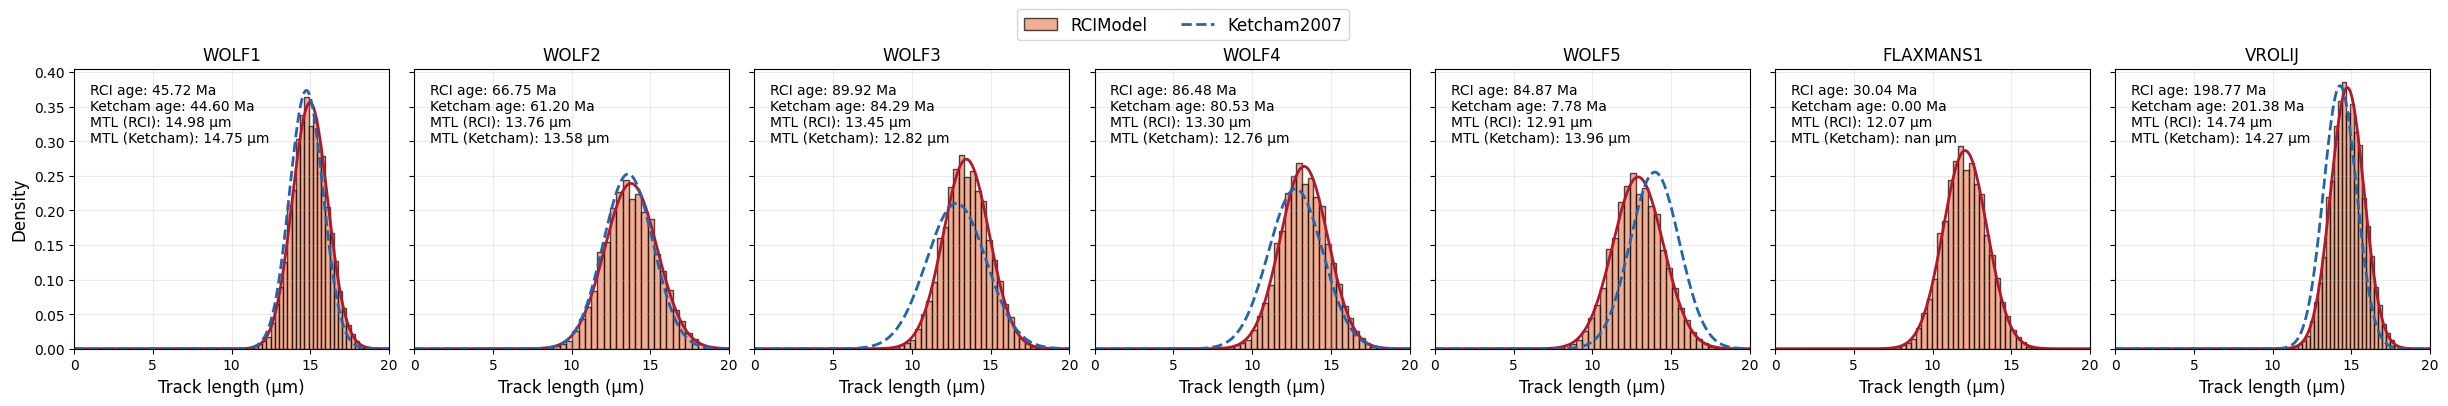

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pyFTracks.thermal_history import (
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
)

histories = [
    WOLF1, WOLF2, WOLF3, WOLF4, WOLF5,
    FLAXMANS1, VROLIJ
]

fig, axes = plt.subplots(
    1, len(histories),
    figsize=(3.6 * len(histories), 4),
    sharey=True
)

for i, th in enumerate(histories):
    run_for_history(th)

    ax = axes[i]

    # =========================
    # RCIModel — histograma + PDF
    # =========================
    mu_rci = annealing_model.MTL
    sigma_rci = annealing_model.STD

    rng = np.random.default_rng(0)
    synthetic_lengths = rng.normal(mu_rci, sigma_rci, size=5000)
    synthetic_lengths = synthetic_lengths[
        (synthetic_lengths > 0) & (synthetic_lengths < 20)
    ]

    ax.hist(
        synthetic_lengths,
        bins=30,
        density=True,
        color=COLOR_RCI_FILL,
        alpha=0.7,
        edgecolor=EDGE_COLOR,
        label="RCIModel"
    )

    x = np.linspace(0, 20, 400)
    ax.plot(
        x,
        norm.pdf(x, mu_rci, sigma_rci),
        color=COLOR_RCI_LINE,
        linewidth=2
    )

    # =========================
    # Ketcham2007 — PDF apenas
    # =========================
    mu_ket = ketcham_model.MTL
    sigma_ket = ketcham_model.STD

    ax.plot(
        x,
        norm.pdf(x, mu_ket, sigma_ket),
        linestyle="--",
        color=COLOR_KETCHAM,
        linewidth=2,
        label="Ketcham2007"
    )

    # =========================
    # Estética
    # =========================
    ax.set_xlim(0, 20)
    ax.set_title(th.name.upper(), fontsize=12)
    ax.grid(True, alpha=0.25)

    ax.text(
        0.05, 0.95,
        f"RCI age: {annealing_model.ft_model_age:.2f} Ma\n"
        f"Ketcham age: {ketcham_model.ft_model_age:.2f} Ma\n"
        f"MTL (RCI): {mu_rci:.2f} µm\n"
        f"MTL (Ketcham): {mu_ket:.2f} µm",
        transform=ax.transAxes,
        fontsize=10,
        va="top"
    )

    if i == 0:
        ax.set_ylabel("Density", fontsize=12)

    ax.set_xlabel("Track length (µm)", fontsize=12)

# =========================
# Legenda global
# =========================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=12,
    bbox_to_anchor=(0.5, 1.05)
)

fig.subplots_adjust(
    left=0.06,
    right=0.995,
    top=0.88,
    bottom=0.18,
    wspace=0.08
)

from pathlib import Path

OUT_DIR = Path("../images")
OUT_DIR.mkdir(exist_ok=True)

plt.savefig(
    OUT_DIR / "wolf_lengths.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
